# 08f — ProteinMPNN Endpoint Energy Comparison

## Pipeline 4 — Final energetic validation of the ProteinMPNN branch

This notebook performs the endpoint energetic analysis for the two
ProteinMPNN leads that survived `08d` and `08e`:

```text
MPNN_NEW_01 = TGPRNQYRDLP
MPNN_NEW_05 = IGPRHQYRDLP
```

Established PEARL references:

```text
F0010
CF06
CF02
```

are **not recalculated** here. Their previous endpoint results from `07e`
are imported for comparison.

---

## Method

For each new candidate, 50 uniformly spaced snapshots are extracted from the
1 ns production trajectory generated in `08e`.

For each snapshot:

```text
ΔE_endpoint =
    E_complex
  - E_receptor
  - E_peptide
```

where all three terms are evaluated with the same AMBER protein force field
and an OBC2 generalized-Born implicit-solvent model.

This is a **single-trajectory MM/GBSA-like endpoint proxy**.

---

## What this is NOT

This quantity is **not** a rigorous absolute binding free energy because it
does not include:

```text
configurational entropy
independent receptor/peptide trajectories
replicate MD uncertainty
full alchemical free-energy treatment
```

It should be interpreted only as a comparative computational energetic
descriptor, consistent with the earlier `07e` analysis.


## 1. Environment check

In [1]:
import sys
from pathlib import Path

print("Python:", sys.version)
print("Working directory:", Path.cwd())

try:
    import openmm
    from openmm import app, unit
    print("OpenMM:", openmm.__version__)
except Exception as exc:
    raise RuntimeError(
        "OpenMM unavailable. Use the Python (PEARL MD) kernel. "
        f"Original error: {exc}"
    )

try:
    import MDAnalysis as mda
    print("MDAnalysis:", mda.__version__)
except Exception as exc:
    raise RuntimeError(
        "MDAnalysis unavailable in the current kernel. "
        f"Original error: {exc}"
    )

print("Environment check: PASS")


Python: 3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:29:05) [Clang 19.1.7 ]
Working directory: /Users/robertobruzzese/Desktop/venv
OpenMM: 8.5.2
MDAnalysis: 2.10.0
Environment check: PASS


## 2. Imports

In [2]:
import json
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openmm import (
    Context,
    VerletIntegrator,
)
from openmm.app import (
    PDBFile,
    Modeller,
    ForceField,
    NoCutoff,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 300)

print("Imports OK")


Imports OK


## 3. Configuration

In [3]:
# ======================================================
# TEST / PRODUCTION SWITCH
# ======================================================
# First run:
#   True  -> 5 uniformly spaced snapshots per candidate
#
# Final run:
#   False -> 50 uniformly spaced snapshots per candidate
FAST_TEST_MODE = True

if FAST_TEST_MODE:
    MODE_LABEL = "smoke_test"
    N_SNAPSHOTS = 5
else:
    MODE_LABEL = "production_50snap"
    N_SNAPSHOTS = 50

# ======================================================
# Candidates
# ======================================================
TARGET_CANDIDATES = [
    "MPNN_NEW_01",
    "MPNN_NEW_05",
]

CANDIDATE_SEQUENCES = {
    "MPNN_NEW_01": "TGPRNQYRDLP",
    "MPNN_NEW_05": "IGPRHQYRDLP",
}

RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

# ======================================================
# 08e production trajectories
# ======================================================
MD_ROOT = (
    Path("outputs")
    / "pipeline_4_ai_08e_top_mpnn_md"
    / "production_1ns"
)

# ======================================================
# Previous 07e endpoint results
# ======================================================
REFERENCE_07E_SEARCH_ROOT = Path("outputs")

REFERENCE_CANDIDATES = [
    "F0010",
    "CF06",
    "CF02",
]

# ======================================================
# Implicit solvent
# ======================================================
SOLUTE_DIELECTRIC = 1.0
SOLVENT_DIELECTRIC = 78.5

# ======================================================
# Bootstrap
# ======================================================
BOOTSTRAP_REPLICATES = 5000
BOOTSTRAP_SEED = 20260811

# ======================================================
# Output
# ======================================================
OUTPUT_ROOT = (
    Path("outputs")
    / "pipeline_4_ai_08f_endpoint_energy"
    / MODE_LABEL
)

TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [
    OUTPUT_ROOT,
    TABLE_DIR,
    REPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("FAST_TEST_MODE:", FAST_TEST_MODE)
print("Mode:", MODE_LABEL)
print("Snapshots per candidate:", N_SNAPSHOTS)
print("Targets:", TARGET_CANDIDATES)
print("Output:", OUTPUT_ROOT.resolve())


FAST_TEST_MODE: True
Mode: smoke_test
Snapshots per candidate: 5
Targets: ['MPNN_NEW_01', 'MPNN_NEW_05']
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08f_endpoint_energy/smoke_test


### Execution protocol

Start with:

```python
FAST_TEST_MODE = True
```

If the complete notebook finishes with:

```text
ALL QC PASSED: True
```

change only:

```python
FAST_TEST_MODE = False
```

then restart the kernel and run all cells.

The final production analysis uses **50 snapshots**, matching the scale used
for `07e`.


## 4. Resolve 08e production files

In [4]:
input_rows = []

for candidate_id in TARGET_CANDIDATES:

    candidate_root = (
        MD_ROOT
        / candidate_id
    )

    traj_dir = (
        candidate_root
        / "trajectory"
    )

    topology_candidates = [
        traj_dir
        / f"{candidate_id}_protein_MDA_topology.pdb",
        traj_dir
        / f"{candidate_id}_protein_topology.pdb",
    ]

    dcd_candidates = [
        traj_dir
        / f"{candidate_id}_production_protein.dcd",
        traj_dir
        / f"{candidate_id}_production_full.dcd",
    ]

    topology = next(
        (
            p for p in topology_candidates
            if p.exists()
        ),
        None,
    )

    # Prefer protein-only DCD.  The full DCD is not accepted
    # unless its atom count matches the protein topology later.
    dcd = next(
        (
            p for p in dcd_candidates
            if p.exists()
        ),
        None,
    )

    input_rows.append({
        "candidate_id": candidate_id,
        "sequence": CANDIDATE_SEQUENCES[
            candidate_id
        ],
        "topology_pdb": (
            str(topology)
            if topology
            else None
        ),
        "trajectory_dcd": (
            str(dcd)
            if dcd
            else None
        ),
        "topology_present": (
            topology is not None
        ),
        "trajectory_present": (
            dcd is not None
        ),
    })

input_df = pd.DataFrame(
    input_rows
)

display(input_df)

if not (
    input_df["topology_present"].all()
    and input_df["trajectory_present"].all()
):
    raise FileNotFoundError(
        "One or more 08e production topology/trajectory files are missing."
    )


,candidate_id,sequence,topology_pdb,trajectory_dcd,topology_present,trajectory_present
0,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,True,True
1,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,True,True


## 5. Validate trajectories

In [5]:
trajectory_qc_rows = []
universes = {}

for _, row in input_df.iterrows():

    candidate_id = row[
        "candidate_id"
    ]

    topology = Path(
        row["topology_pdb"]
    )

    dcd = Path(
        row["trajectory_dcd"]
    )

    try:
        u = mda.Universe(
            str(topology),
            str(dcd),
        )
    except Exception as exc:
        raise RuntimeError(
            f"Could not load trajectory for {candidate_id}.\n"
            f"Topology: {topology}\n"
            f"DCD: {dcd}\n"
            f"Original error: {exc}"
        )

    universes[
        candidate_id
    ] = u

    trajectory_qc_rows.append({
        "candidate_id": candidate_id,
        "n_atoms": u.atoms.n_atoms,
        "n_frames": len(
            u.trajectory
        ),
        "topology_pdb": str(topology),
        "trajectory_dcd": str(dcd),
    })

trajectory_qc_df = pd.DataFrame(
    trajectory_qc_rows
)

display(trajectory_qc_df)

if (
    trajectory_qc_df[
        "n_frames"
    ].min()
    < N_SNAPSHOTS
):
    raise RuntimeError(
        "Not enough production frames for the requested snapshot count."
    )


,candidate_id,n_atoms,n_frames,topology_pdb,trajectory_dcd
0,MPNN_NEW_01,9469,500,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...
1,MPNN_NEW_05,9477,500,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...,outputs/pipeline_4_ai_08e_top_mpnn_md/producti...


## 6. Confirm chain identities and peptide sequences

In [6]:
def select_chain(
    universe,
    chain_id,
):
    for selection in [
        f"protein and chainID {chain_id}",
        f"protein and segid {chain_id}",
    ]:
        atoms = universe.select_atoms(
            selection
        )

        if atoms.n_atoms > 0:
            return atoms

    raise RuntimeError(
        f"Could not select chain {chain_id}"
    )


chain_qc_rows = []

for candidate_id, u in universes.items():

    receptor = select_chain(
        u,
        RECEPTOR_CHAIN,
    )

    peptide = select_chain(
        u,
        PEPTIDE_CHAIN,
    )

    peptide_residues = peptide.residues

    # Sequence from MDAnalysis residue names.
    THREE_TO_ONE = {
        "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
        "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
        "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
        "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
        "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    }

    observed_sequence = "".join(
        THREE_TO_ONE.get(
            res.resname,
            "X",
        )
        for res in peptide_residues
    )

    expected_sequence = (
        CANDIDATE_SEQUENCES[
            candidate_id
        ]
    )

    chain_qc_rows.append({
        "candidate_id": candidate_id,
        "receptor_atoms": receptor.n_atoms,
        "peptide_atoms": peptide.n_atoms,
        "peptide_residues": len(
            peptide_residues
        ),
        "expected_sequence": expected_sequence,
        "observed_sequence": observed_sequence,
        "sequence_match": (
            observed_sequence
            == expected_sequence
        ),
    })

chain_qc_df = pd.DataFrame(
    chain_qc_rows
)

display(chain_qc_df)

if not chain_qc_df[
    "sequence_match"
].all():
    raise RuntimeError(
        "Peptide sequence mismatch in one or more 08e production topologies."
    )


,candidate_id,receptor_atoms,peptide_atoms,peptide_residues,expected_sequence,observed_sequence,sequence_match
0,MPNN_NEW_01,9286,183,11,TGPRNQYRDLP,TGPRNQYRDLP,True
1,MPNN_NEW_05,9286,191,11,IGPRHQYRDLP,IGPRHQYRDLP,True


## 7. Select uniform production snapshots

In [7]:
snapshot_rows = []
snapshot_indices = {}

for candidate_id, u in universes.items():

    n_frames = len(
        u.trajectory
    )

    indices = np.linspace(
        0,
        n_frames - 1,
        N_SNAPSHOTS,
        dtype=int,
    )

    # Defensive uniqueness check.
    indices = np.unique(
        indices
    )

    if len(indices) != N_SNAPSHOTS:
        raise RuntimeError(
            f"Snapshot selection for {candidate_id} "
            f"returned {len(indices)} unique frames, "
            f"expected {N_SNAPSHOTS}."
        )

    snapshot_indices[
        candidate_id
    ] = indices

    for rank, idx in enumerate(
        indices,
        start=1,
    ):
        snapshot_rows.append({
            "candidate_id": candidate_id,
            "snapshot_number": rank,
            "frame_index": int(idx),
            "frame_fraction": (
                idx
                / max(
                    1,
                    n_frames - 1,
                )
            ),
        })

snapshot_df = pd.DataFrame(
    snapshot_rows
)

display(snapshot_df)

snapshot_df.to_csv(
    TABLE_DIR
    / "08f_selected_snapshot_indices.csv",
    index=False,
)


,candidate_id,snapshot_number,frame_index,frame_fraction
0,MPNN_NEW_01,1,0,0.000000
1,MPNN_NEW_01,2,124,0.248497
2,MPNN_NEW_01,3,249,0.498998
3,MPNN_NEW_01,4,374,0.749499
4,MPNN_NEW_01,5,499,1.000000
5,MPNN_NEW_05,1,0,0.000000
6,MPNN_NEW_05,2,124,0.248497
7,MPNN_NEW_05,3,249,0.498998
8,MPNN_NEW_05,4,374,0.749499
9,MPNN_NEW_05,5,499,1.000000


## 8. Load the endpoint force field

In [8]:
FORCEFIELD_CANDIDATES = [
    (
        "amber14/protein.ff14SB.xml",
        "implicit/obc2.xml",
    ),
    (
        "amber14-all.xml",
        "implicit/obc2.xml",
    ),
]

endpoint_forcefield = None
endpoint_forcefield_names = None
last_forcefield_error = None

for ff_names in FORCEFIELD_CANDIDATES:
    try:
        endpoint_forcefield = ForceField(
            *ff_names
        )

        endpoint_forcefield_names = (
            ff_names
        )

        break

    except Exception as exc:
        last_forcefield_error = exc

if endpoint_forcefield is None:
    raise RuntimeError(
        "Could not load AMBER + OBC2 endpoint force field. "
        f"Last error: {last_forcefield_error}"
    )

print(
    "Endpoint force field:",
    endpoint_forcefield_names,
)


Endpoint force field: ('amber14/protein.ff14SB.xml', 'implicit/obc2.xml')


The endpoint analysis uses an AMBER protein force field together with
the OBC2 generalized-Born implicit-solvent model.

OpenMM supports AMBER force fields with separate implicit-solvent XML files,
including `implicit/obc2.xml`; the nonbonded method used here is `NoCutoff`.


## 9. OpenMM platform for energy evaluation

In [11]:
available_platforms = [
    openmm.Platform.getPlatform(i).getName()
    for i in range(openmm.Platform.getNumPlatforms())
]

print(
    "Available OpenMM platforms:",
    available_platforms,
)

# Prefer GPU acceleration on Apple Silicon if available.
if "Metal" in available_platforms:
    ENERGY_PLATFORM = openmm.Platform.getPlatformByName("Metal")
    ENERGY_PLATFORM_PROPERTIES = {}

elif "OpenCL" in available_platforms:
    ENERGY_PLATFORM = openmm.Platform.getPlatformByName("OpenCL")
    ENERGY_PLATFORM_PROPERTIES = {}

elif "CPU" in available_platforms:
    ENERGY_PLATFORM = openmm.Platform.getPlatformByName("CPU")
    ENERGY_PLATFORM_PROPERTIES = {}

else:
    raise RuntimeError(
        "No suitable OpenMM platform available."
    )

print(
    "Energy platform:",
    ENERGY_PLATFORM.getName(),
)

Available OpenMM platforms: ['Reference', 'CPU', 'OpenCL']
Energy platform: OpenCL


In [10]:
print(available_platforms)

['Reference', 'CPU', 'OpenCL']


## 10. Helpers for OpenMM subsystem construction

In [12]:
def get_openmm_chain_ids(
    topology,
):
    return [
        chain.id
        for chain in topology.chains()
    ]


def build_subsystem_modeller(
    pdb,
    keep_chain_ids,
):
    keep_chain_ids = set(
        keep_chain_ids
    )

    modeller = Modeller(
        pdb.topology,
        pdb.positions,
    )

    atoms_to_delete = [
        atom
        for atom in modeller.topology.atoms()
        if atom.residue.chain.id
        not in keep_chain_ids
    ]

    modeller.delete(
        atoms_to_delete
    )

    return modeller


def create_endpoint_system(
    topology,
):
    return endpoint_forcefield.createSystem(
        topology,
        nonbondedMethod=NoCutoff,
        constraints=None,
        rigidWater=False,
        removeCMMotion=False,
        soluteDielectric=SOLUTE_DIELECTRIC,
        solventDielectric=SOLVENT_DIELECTRIC,
    )


## 11. Prepare complex, receptor and peptide endpoint systems

In [13]:
system_rows = []
endpoint_objects = {}

for _, row in input_df.iterrows():

    candidate_id = row[
        "candidate_id"
    ]

    topology_pdb = Path(
        row["topology_pdb"]
    )

    pdb = PDBFile(
        str(topology_pdb)
    )

    chain_ids = get_openmm_chain_ids(
        pdb.topology
    )

    print(
        candidate_id,
        "OpenMM chain IDs:",
        chain_ids,
    )

    if (
        RECEPTOR_CHAIN
        not in chain_ids
        or PEPTIDE_CHAIN
        not in chain_ids
    ):
        raise RuntimeError(
            f"{candidate_id}: required chains B/D not found "
            f"in OpenMM topology: {chain_ids}"
        )

    complex_modeller = (
        build_subsystem_modeller(
            pdb,
            [
                RECEPTOR_CHAIN,
                PEPTIDE_CHAIN,
            ],
        )
    )

    receptor_modeller = (
        build_subsystem_modeller(
            pdb,
            [
                RECEPTOR_CHAIN,
            ],
        )
    )

    peptide_modeller = (
        build_subsystem_modeller(
            pdb,
            [
                PEPTIDE_CHAIN,
            ],
        )
    )

    complex_system = create_endpoint_system(
        complex_modeller.topology
    )

    receptor_system = create_endpoint_system(
        receptor_modeller.topology
    )

    peptide_system = create_endpoint_system(
        peptide_modeller.topology
    )

    endpoint_objects[
        candidate_id
    ] = {
        "complex_modeller": complex_modeller,
        "receptor_modeller": receptor_modeller,
        "peptide_modeller": peptide_modeller,
        "complex_system": complex_system,
        "receptor_system": receptor_system,
        "peptide_system": peptide_system,
    }

    system_rows.append({
        "candidate_id": candidate_id,
        "complex_atoms": complex_system.getNumParticles(),
        "receptor_atoms": receptor_system.getNumParticles(),
        "peptide_atoms": peptide_system.getNumParticles(),
        "atom_partition_valid": (
            complex_system.getNumParticles()
            == (
                receptor_system.getNumParticles()
                + peptide_system.getNumParticles()
            )
        ),
    })

system_qc_df = pd.DataFrame(
    system_rows
)

display(system_qc_df)

if not system_qc_df[
    "atom_partition_valid"
].all():
    raise RuntimeError(
        "Complex atom count does not equal receptor + peptide atom counts."
    )


MPNN_NEW_01 OpenMM chain IDs: ['B', 'D']
MPNN_NEW_05 OpenMM chain IDs: ['B', 'D']


,candidate_id,complex_atoms,receptor_atoms,peptide_atoms,atom_partition_valid
0,MPNN_NEW_01,9469,9286,183,True
1,MPNN_NEW_05,9477,9286,191,True


## 12. Energy-context helper

For each candidate, three OpenMM contexts are created once:

```text
complex
receptor
peptide
```

Coordinates are updated snapshot-by-snapshot.

No minimization is performed here.  This preserves the **single-trajectory**
endpoint logic: receptor and peptide energies are evaluated in the exact
coordinates they have in the complex snapshot.


In [14]:
def make_energy_context(
    system,
):
    integrator = VerletIntegrator(
        0.001
        * unit.picoseconds
    )

    context = Context(
        system,
        integrator,
        ENERGY_PLATFORM,
        ENERGY_PLATFORM_PROPERTIES,
    )

    return context, integrator


def get_potential_kcal_mol(
    context,
    positions_nm,
):
    context.setPositions(
        positions_nm
        * unit.nanometer
    )

    state = context.getState(
        getEnergy=True
    )

    return float(
        state.getPotentialEnergy().value_in_unit(
            unit.kilocalories_per_mole
        )
    )


## 13. Map trajectory atom indices for B/D subsystems

In [15]:
index_maps = {}

for candidate_id, u in universes.items():

    receptor = select_chain(
        u,
        RECEPTOR_CHAIN,
    )

    peptide = select_chain(
        u,
        PEPTIDE_CHAIN,
    )

    complex_atoms = u.select_atoms(
        (
            f"(protein and chainID {RECEPTOR_CHAIN}) "
            f"or (protein and chainID {PEPTIDE_CHAIN})"
        )
    )

    if complex_atoms.n_atoms == 0:
        complex_atoms = u.select_atoms(
            (
                f"(protein and segid {RECEPTOR_CHAIN}) "
                f"or (protein and segid {PEPTIDE_CHAIN})"
            )
        )

    if complex_atoms.n_atoms == 0:
        raise RuntimeError(
            f"{candidate_id}: could not select B+D complex atoms."
        )

    obj = endpoint_objects[
        candidate_id
    ]

    expected_complex = (
        obj[
            "complex_system"
        ].getNumParticles()
    )

    expected_receptor = (
        obj[
            "receptor_system"
        ].getNumParticles()
    )

    expected_peptide = (
        obj[
            "peptide_system"
        ].getNumParticles()
    )

    observed = {
        "complex": complex_atoms.n_atoms,
        "receptor": receptor.n_atoms,
        "peptide": peptide.n_atoms,
    }

    expected = {
        "complex": expected_complex,
        "receptor": expected_receptor,
        "peptide": expected_peptide,
    }

    print(
        candidate_id,
        "observed:",
        observed,
        "expected:",
        expected,
    )

    if observed != expected:
        raise RuntimeError(
            f"{candidate_id}: MDAnalysis/OpenMM atom-count mismatch."
        )

    index_maps[
        candidate_id
    ] = {
        "complex": complex_atoms.indices.copy(),
        "receptor": receptor.indices.copy(),
        "peptide": peptide.indices.copy(),
    }


MPNN_NEW_01 observed: {'complex': 9469, 'receptor': 9286, 'peptide': 183} expected: {'complex': 9469, 'receptor': 9286, 'peptide': 183}
MPNN_NEW_05 observed: {'complex': 9477, 'receptor': 9286, 'peptide': 191} expected: {'complex': 9477, 'receptor': 9286, 'peptide': 191}


## 14. Evaluate endpoint energies

In [16]:
energy_rows = []

for candidate_id in TARGET_CANDIDATES:

    print()
    print("=" * 70)
    print(candidate_id)
    print("=" * 70)

    u = universes[
        candidate_id
    ]

    obj = endpoint_objects[
        candidate_id
    ]

    maps = index_maps[
        candidate_id
    ]

    complex_context, complex_integrator = (
        make_energy_context(
            obj[
                "complex_system"
            ]
        )
    )

    receptor_context, receptor_integrator = (
        make_energy_context(
            obj[
                "receptor_system"
            ]
        )
    )

    peptide_context, peptide_integrator = (
        make_energy_context(
            obj[
                "peptide_system"
            ]
        )
    )

    indices = snapshot_indices[
        candidate_id
    ]

    t0 = time.time()

    for snapshot_number, frame_index in enumerate(
        indices,
        start=1,
    ):

        u.trajectory[
            int(frame_index)
        ]

        all_positions_a = (
            u.atoms.positions.copy()
        )

        # MDAnalysis positions are in Å.
        all_positions_nm = (
            all_positions_a
            * 0.1
        )

        complex_positions_nm = (
            all_positions_nm[
                maps["complex"]
            ]
        )

        receptor_positions_nm = (
            all_positions_nm[
                maps["receptor"]
            ]
        )

        peptide_positions_nm = (
            all_positions_nm[
                maps["peptide"]
            ]
        )

        E_complex = (
            get_potential_kcal_mol(
                complex_context,
                complex_positions_nm,
            )
        )

        E_receptor = (
            get_potential_kcal_mol(
                receptor_context,
                receptor_positions_nm,
            )
        )

        E_peptide = (
            get_potential_kcal_mol(
                peptide_context,
                peptide_positions_nm,
            )
        )

        delta_E = (
            E_complex
            - E_receptor
            - E_peptide
        )

        energy_rows.append({
            "candidate_id": candidate_id,
            "snapshot_number": snapshot_number,
            "frame_index": int(
                frame_index
            ),
            "E_complex_kcal_mol": E_complex,
            "E_receptor_kcal_mol": E_receptor,
            "E_peptide_kcal_mol": E_peptide,
            "delta_E_endpoint_kcal_mol": delta_E,
        })

        print(
            f"{candidate_id} "
            f"{snapshot_number:02d}/{len(indices)} "
            f"frame={frame_index} "
            f"ΔE={delta_E:.3f} kcal/mol"
        )

    elapsed = (
        time.time()
        - t0
    )

    print(
        f"{candidate_id} endpoint runtime: "
        f"{elapsed/60:.2f} min"
    )

    # Explicitly release contexts/integrators.
    del complex_context
    del receptor_context
    del peptide_context
    del complex_integrator
    del receptor_integrator
    del peptide_integrator


endpoint_snapshot_df = pd.DataFrame(
    energy_rows
)

endpoint_snapshot_df.to_csv(
    TABLE_DIR
    / "08f_endpoint_snapshot_energies.csv",
    index=False,
)

display(
    endpoint_snapshot_df.head(20)
)



MPNN_NEW_01
MPNN_NEW_01 01/5 frame=0 ΔE=-49.970 kcal/mol
MPNN_NEW_01 02/5 frame=124 ΔE=-51.348 kcal/mol
MPNN_NEW_01 03/5 frame=249 ΔE=-49.191 kcal/mol
MPNN_NEW_01 04/5 frame=374 ΔE=-44.302 kcal/mol
MPNN_NEW_01 05/5 frame=499 ΔE=-40.157 kcal/mol
MPNN_NEW_01 endpoint runtime: 0.01 min

MPNN_NEW_05
MPNN_NEW_05 01/5 frame=0 ΔE=-55.906 kcal/mol
MPNN_NEW_05 02/5 frame=124 ΔE=-50.146 kcal/mol
MPNN_NEW_05 03/5 frame=249 ΔE=-53.781 kcal/mol
MPNN_NEW_05 04/5 frame=374 ΔE=-62.016 kcal/mol
MPNN_NEW_05 05/5 frame=499 ΔE=-41.881 kcal/mol
MPNN_NEW_05 endpoint runtime: 0.01 min


,candidate_id,snapshot_number,frame_index,E_complex_kcal_mol,E_receptor_kcal_mol,E_peptide_kcal_mol,delta_E_endpoint_kcal_mol
0,MPNN_NEW_01,1,0,-13889.293452,-13190.008466,-649.314679,-49.970307
1,MPNN_NEW_01,2,124,-13988.021019,-13275.913308,-660.759930,-51.347782
2,MPNN_NEW_01,3,249,-13849.230385,-13159.686404,-640.352998,-49.190983
3,MPNN_NEW_01,4,374,-13921.007087,-13236.059546,-640.645278,-44.302263
4,MPNN_NEW_01,5,499,-14055.565398,-13358.516788,-656.891748,-40.156862
5,MPNN_NEW_05,1,0,-13704.470195,-13148.312264,-500.252081,-55.905850
6,MPNN_NEW_05,2,124,-13762.045997,-13197.567949,-514.332029,-50.146019
7,MPNN_NEW_05,3,249,-13813.828054,-13243.019870,-517.027014,-53.781171
8,MPNN_NEW_05,4,374,-13815.880442,-13243.272829,-510.591256,-62.016357
9,MPNN_NEW_05,5,499,-13879.289762,-13325.565790,-511.842929,-41.881043


## 15. New-candidate endpoint summary

In [17]:
new_endpoint_summary_df = (
    endpoint_snapshot_df.groupby(
        "candidate_id",
        as_index=False,
    )[
        "delta_E_endpoint_kcal_mol"
    ]
    .agg(
        mean_delta_E_endpoint_kcal_mol="mean",
        sd_delta_E_endpoint_kcal_mol="std",
        median_delta_E_endpoint_kcal_mol="median",
        min_delta_E_endpoint_kcal_mol="min",
        max_delta_E_endpoint_kcal_mol="max",
        n_snapshots="count",
    )
)

new_endpoint_summary_df = (
    new_endpoint_summary_df
    .sort_values(
        "mean_delta_E_endpoint_kcal_mol",
        ascending=True,
    )
    .reset_index(drop=True)
)

new_endpoint_summary_df.insert(
    0,
    "new_candidate_endpoint_rank",
    np.arange(
        len(
            new_endpoint_summary_df
        )
    ) + 1,
)

display(
    new_endpoint_summary_df
)

new_endpoint_summary_df.to_csv(
    TABLE_DIR
    / "08f_new_candidate_endpoint_summary.csv",
    index=False,
)


,new_candidate_endpoint_rank,candidate_id,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,median_delta_E_endpoint_kcal_mol,min_delta_E_endpoint_kcal_mol,max_delta_E_endpoint_kcal_mol,n_snapshots
0,1,MPNN_NEW_05,-52.746088,7.446525,-53.781171,-62.016357,-41.881043,5
1,2,MPNN_NEW_01,-46.993639,4.653828,-49.190983,-51.347782,-40.156862,5


## 16. Endpoint energy distribution plot

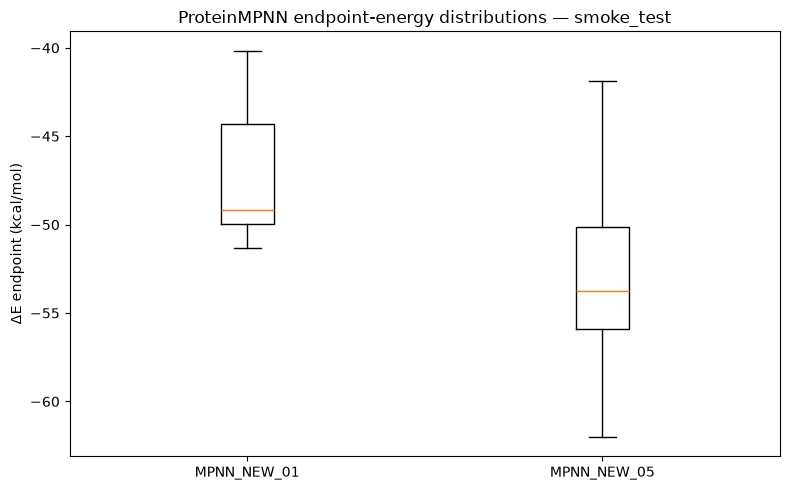

In [18]:
plt.figure(
    figsize=(8, 5)
)

data = [
    endpoint_snapshot_df.loc[
        endpoint_snapshot_df[
            "candidate_id"
        ]
        == candidate_id,
        "delta_E_endpoint_kcal_mol",
    ].values
    for candidate_id in TARGET_CANDIDATES
]

plt.boxplot(
    data,
    tick_labels=TARGET_CANDIDATES,
)

plt.ylabel(
    "ΔE endpoint (kcal/mol)"
)
plt.title(
    f"ProteinMPNN endpoint-energy distributions — {MODE_LABEL}"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "08f_new_candidate_endpoint_boxplot.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 17. Bootstrap pairwise difference between the two new candidates

The bootstrap is descriptive only.

Snapshots from a trajectory are time-correlated, so these intervals must not
be interpreted as formal independent-sample confidence intervals.


In [19]:
rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

a_name = TARGET_CANDIDATES[0]
b_name = TARGET_CANDIDATES[1]

a = endpoint_snapshot_df.loc[
    endpoint_snapshot_df[
        "candidate_id"
    ]
    == a_name,
    "delta_E_endpoint_kcal_mol",
].to_numpy()

b = endpoint_snapshot_df.loc[
    endpoint_snapshot_df[
        "candidate_id"
    ]
    == b_name,
    "delta_E_endpoint_kcal_mol",
].to_numpy()

bootstrap_differences = np.empty(
    BOOTSTRAP_REPLICATES,
    dtype=float,
)

for i in range(
    BOOTSTRAP_REPLICATES
):
    a_boot = rng.choice(
        a,
        size=len(a),
        replace=True,
    )

    b_boot = rng.choice(
        b,
        size=len(b),
        replace=True,
    )

    bootstrap_differences[i] = (
        np.mean(a_boot)
        - np.mean(b_boot)
    )

bootstrap_summary_df = pd.DataFrame([
    {
        "comparison": (
            f"{a_name} - {b_name}"
        ),
        "mean_difference_kcal_mol": float(
            np.mean(
                bootstrap_differences
            )
        ),
        "ci_2.5pct": float(
            np.quantile(
                bootstrap_differences,
                0.025,
            )
        ),
        "ci_97.5pct": float(
            np.quantile(
                bootstrap_differences,
                0.975,
            )
        ),
        "fraction_first_more_favorable": float(
            np.mean(
                bootstrap_differences
                < 0
            )
        ),
    }
])

display(
    bootstrap_summary_df
)

bootstrap_summary_df.to_csv(
    TABLE_DIR
    / "08f_new_candidate_bootstrap_comparison.csv",
    index=False,
)


,comparison,mean_difference_kcal_mol,ci_2.5pct,ci_97.5pct,fraction_first_more_favorable
0,MPNN_NEW_01 - MPNN_NEW_05,5.663923,-1.188095,12.397517,0.0544


## 18. Locate the previous 07e reference summary

The notebook searches for a CSV containing:

```text
F0010
CF06
CF02
```

and a mean endpoint-energy column.

No previous energies are recomputed.


In [20]:
reference_candidates_found = []

for p in REFERENCE_07E_SEARCH_ROOT.rglob(
    "*.csv"
):
    low = str(p).lower()

    if (
        "07e" not in low
        and "endpoint" not in low
        and "mmgbsa" not in low
    ):
        continue

    try:
        df = pd.read_csv(
            p
        )
    except Exception:
        continue

    candidate_col = next(
        (
            c for c in df.columns
            if str(c).lower()
            in {
                "candidate",
                "candidate_id",
                "name",
            }
        ),
        None,
    )

    if candidate_col is None:
        continue

    values = set(
        df[
            candidate_col
        ]
        .astype(str)
    )

    if not set(
        REFERENCE_CANDIDATES
    ).issubset(
        values
    ):
        continue

    energy_col = next(
        (
            c for c in df.columns
            if (
                "mean"
                in str(c).lower()
                and "delta"
                in str(c).lower()
                and (
                    "energy"
                    in str(c).lower()
                    or "_e"
                    in str(c).lower()
                )
            )
        ),
        None,
    )

    if energy_col is None:
        energy_col = next(
            (
                c for c in df.columns
                if (
                    "mean_delta_e"
                    in str(c).lower()
                )
            ),
            None,
        )

    if energy_col is None:
        continue

    reference_candidates_found.append(
        (
            p,
            df,
            candidate_col,
            energy_col,
        )
    )

print(
    "Potential 07e reference summaries:",
    len(
        reference_candidates_found
    ),
)

for (
    p,
    df,
    candidate_col,
    energy_col,
) in reference_candidates_found[:20]:
    print(
        p,
        "| candidate:",
        candidate_col,
        "| energy:",
        energy_col,
    )


Potential 07e reference summaries: 4
outputs/pipeline_3_md_07e_mmgbsa_endpoint_comparison/tables/07e_endpoint_energy_summary.csv | candidate: candidate | energy: mean_delta_E_endpoint_kcal_mol
outputs/pipeline_3_md_07e_mmgbsa_endpoint_comparison/tables/07e_relative_to_F0010.csv | candidate: candidate | energy: mean_delta_E_endpoint_kcal_mol
outputs/pipeline_3_md_07e_mmgbsa_endpoint_comparison/tables/07e_dynamic_energetic_integration.csv | candidate: candidate | energy: mean_delta_E_endpoint_kcal_mol
outputs/pipeline_4_ai_08a_esm2_sequence_scoring/tables/08a_ESM2_MD_endpoint_integration.csv | candidate: candidate | energy: mean_delta_E_endpoint_kcal_mol


## 19. Import established 07e endpoint results

In [21]:
reference_endpoint_df = None
reference_source_path = None
reference_candidate_col = None
reference_energy_col = None

# Prefer a compact summary table.
sorted_reference_candidates = sorted(
    reference_candidates_found,
    key=lambda x: (
        len(x[1]),
        len(str(x[0])),
    ),
)

for (
    p,
    df,
    candidate_col,
    energy_col,
) in sorted_reference_candidates:

    subset = df[
        df[
            candidate_col
        ]
        .astype(str)
        .isin(
            REFERENCE_CANDIDATES
        )
    ].copy()

    unique_candidates = set(
        subset[
            candidate_col
        ].astype(str)
    )

    if unique_candidates != set(
        REFERENCE_CANDIDATES
    ):
        continue

    # Require one row per reference candidate.
    if len(subset) != 3:
        continue

    reference_endpoint_df = subset
    reference_source_path = p
    reference_candidate_col = candidate_col
    reference_energy_col = energy_col

    break


if reference_endpoint_df is None:
    print(
        "07e compact reference summary was not identified automatically."
    )
else:
    print(
        "Using 07e reference:",
        reference_source_path,
    )

    display(
        reference_endpoint_df
    )


Using 07e reference: outputs/pipeline_3_md_07e_mmgbsa_endpoint_comparison/tables/07e_relative_to_F0010.csv


,candidate,sequence,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,sem_delta_E_endpoint_kcal_mol,delta_vs_F0010_kcal_mol,interpretation_vs_F0010
0,CF06,IGERCQYRELR,-65.661216,6.801657,0.961900,-6.203512,more favorable endpoint proxy
1,F0010,IGERCQYRDLK,-59.457704,5.958218,0.842619,0.000000,reference
2,CF02,IGERSQYRELK,-56.619600,4.628475,0.654565,2.838104,less favorable endpoint proxy


## 20. Harmonize new and established endpoint results

In [22]:
comparison_rows = []

for _, row in new_endpoint_summary_df.iterrows():

    comparison_rows.append({
        "candidate_id": row[
            "candidate_id"
        ],
        "source": "08f_new_ProteinMPNN",
        "mean_delta_E_endpoint_kcal_mol": row[
            "mean_delta_E_endpoint_kcal_mol"
        ],
        "sd_delta_E_endpoint_kcal_mol": row[
            "sd_delta_E_endpoint_kcal_mol"
        ],
        "n_snapshots": row[
            "n_snapshots"
        ],
    })


if reference_endpoint_df is not None:

    # Find optional SD column.
    reference_sd_col = next(
        (
            c for c in reference_endpoint_df.columns
            if (
                "sd"
                in str(c).lower()
                and "delta"
                in str(c).lower()
            )
        ),
        None,
    )

    for _, row in reference_endpoint_df.iterrows():

        comparison_rows.append({
            "candidate_id": str(
                row[
                    reference_candidate_col
                ]
            ),
            "source": "07e_established_reference",
            "mean_delta_E_endpoint_kcal_mol": float(
                row[
                    reference_energy_col
                ]
            ),
            "sd_delta_E_endpoint_kcal_mol": (
                float(
                    row[
                        reference_sd_col
                    ]
                )
                if (
                    reference_sd_col
                    and pd.notna(
                        row[
                            reference_sd_col
                        ]
                    )
                )
                else np.nan
            ),
            "n_snapshots": (
                int(
                    row["n_snapshots"]
                )
                if (
                    "n_snapshots"
                    in reference_endpoint_df.columns
                    and pd.notna(
                        row[
                            "n_snapshots"
                        ]
                    )
                )
                else 50
            ),
        })


comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df = (
    comparison_df
    .sort_values(
        "mean_delta_E_endpoint_kcal_mol",
        ascending=True,
    )
    .reset_index(drop=True)
)

comparison_df.insert(
    0,
    "endpoint_rank",
    np.arange(
        len(
            comparison_df
        )
    ) + 1,
)

display(
    comparison_df
)

comparison_df.to_csv(
    TABLE_DIR
    / "08f_endpoint_comparison_with_07e.csv",
    index=False,
)


,endpoint_rank,candidate_id,source,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,n_snapshots
0,1,CF06,07e_established_reference,-65.661216,6.801657,50
1,2,F0010,07e_established_reference,-59.457704,5.958218,50
2,3,CF02,07e_established_reference,-56.619600,4.628475,50
3,4,MPNN_NEW_05,08f_new_ProteinMPNN,-52.746088,7.446525,5
4,5,MPNN_NEW_01,08f_new_ProteinMPNN,-46.993639,4.653828,5


## 21. Combined endpoint comparison plot

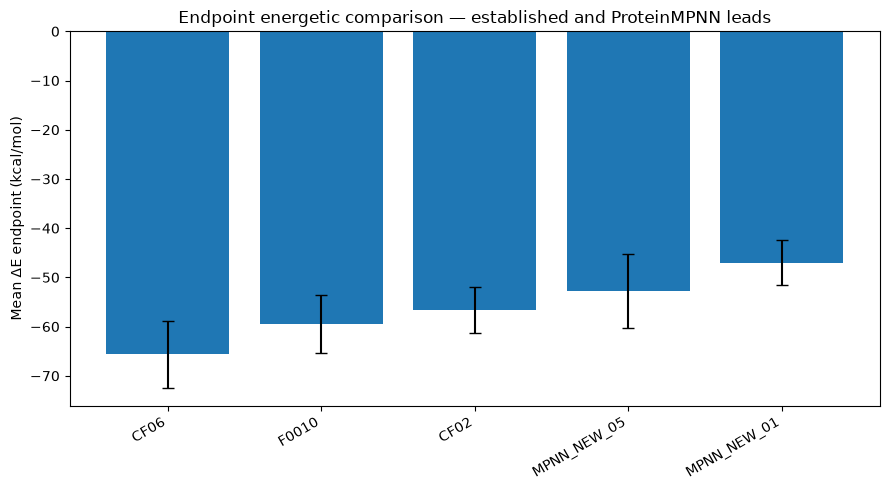

In [23]:
if len(
    comparison_df
) > 0:

    plot_df = comparison_df.copy()

    plt.figure(
        figsize=(9, 5)
    )

    plt.bar(
        plot_df[
            "candidate_id"
        ],
        plot_df[
            "mean_delta_E_endpoint_kcal_mol"
        ],
        yerr=plot_df[
            "sd_delta_E_endpoint_kcal_mol"
        ].fillna(0),
        capsize=4,
    )

    plt.ylabel(
        "Mean ΔE endpoint (kcal/mol)"
    )

    plt.title(
        "Endpoint energetic comparison — established and ProteinMPNN leads"
    )

    plt.xticks(
        rotation=30,
        ha="right",
    )

    plt.tight_layout()

    plt.savefig(
        REPORT_DIR
        / "08f_endpoint_comparison.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


## 22. Cross-method evidence matrix

This combines the final endpoint result with the most important previous
Pipeline 4 outputs when they can be located automatically.

The matrix is descriptive.  Metrics from different methods are not converted
into a single physical score.


In [24]:
evidence_rows = []

for candidate_id in TARGET_CANDIDATES:

    endpoint_row = (
        new_endpoint_summary_df[
            new_endpoint_summary_df[
                "candidate_id"
            ]
            == candidate_id
        ]
        .iloc[0]
    )

    evidence_rows.append({
        "candidate_id": candidate_id,
        "sequence": CANDIDATE_SEQUENCES[
            candidate_id
        ],
        "mean_delta_E_endpoint_kcal_mol": endpoint_row[
            "mean_delta_E_endpoint_kcal_mol"
        ],
        "sd_delta_E_endpoint_kcal_mol": endpoint_row[
            "sd_delta_E_endpoint_kcal_mol"
        ],
    })


evidence_df = pd.DataFrame(
    evidence_rows
)

# 08d structural ranking.
structural_path = (
    Path("outputs")
    / "pipeline_4_ai_08d_structural_validation"
    / "tables"
    / "08d_integrated_structural_ranking.csv"
)

if structural_path.exists():

    s = pd.read_csv(
        structural_path
    )

    keep = [
        c for c in [
            "candidate_id",
            "AI_integrated_score",
            "ESM2_PLL_mean",
            "best_ProteinMPNN_score",
            "foldx_interaction_energy_kcal_mol",
            "best_I_sc",
            "structural_rank",
            "structural_rank_sum",
        ]
        if c in s.columns
    ]

    evidence_df = evidence_df.merge(
        s[keep],
        on="candidate_id",
        how="left",
    )


# 08e MD summary.
md_summary_path = (
    Path("outputs")
    / "pipeline_4_ai_08e_top_mpnn_md"
    / "production_1ns"
    / "tables"
    / "08e_new_candidate_MD_summary.csv"
)

if md_summary_path.exists():

    m = pd.read_csv(
        md_summary_path
    )

    keep = [
        c for c in [
            "candidate_id",
            "mean_peptide_CA_RMSD_A",
            "mean_peptide_CA_RMSF_A",
            "n_persistent_contacts_50pct",
            "mean_contact_persistence",
        ]
        if c in m.columns
    ]

    evidence_df = evidence_df.merge(
        m[keep],
        on="candidate_id",
        how="left",
    )


display(
    evidence_df
)

evidence_df.to_csv(
    TABLE_DIR
    / "08f_ProteinMPNN_cross_method_evidence.csv",
    index=False,
)


,candidate_id,sequence,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,AI_integrated_score,ESM2_PLL_mean,best_ProteinMPNN_score,foldx_interaction_energy_kcal_mol,best_I_sc,structural_rank,structural_rank_sum,mean_peptide_CA_RMSD_A,mean_peptide_CA_RMSF_A,n_persistent_contacts_50pct,mean_contact_persistence
0,MPNN_NEW_01,TGPRNQYRDLP,-46.993639,4.653828,0.601249,-3.172003,1.2473,-11.7407,-54.169,2,5.0,1.267912,0.919858,41,0.599029
1,MPNN_NEW_05,IGPRHQYRDLP,-52.746088,7.446525,0.508830,-3.174593,1.4079,-13.7478,-56.118,1,2.0,1.417030,0.830541,40,0.535395


## 23. Automatic QC

In [25]:
qc_rows = [
    {
        "check": "two_production_trajectories_loaded",
        "pass": (
            len(
                trajectory_qc_df
            )
            == 2
        ),
    },
    {
        "check": "peptide_sequences_match",
        "pass": bool(
            chain_qc_df[
                "sequence_match"
            ].all()
        ),
    },
    {
        "check": "requested_snapshot_count",
        "pass": bool(
            (
                endpoint_snapshot_df.groupby(
                    "candidate_id"
                )
                .size()
                == N_SNAPSHOTS
            ).all()
        ),
    },
    {
        "check": "endpoint_values_finite",
        "pass": bool(
            np.isfinite(
                endpoint_snapshot_df[
                    "delta_E_endpoint_kcal_mol"
                ].to_numpy(
                    dtype=float
                )
            ).all()
        ),
    },
    {
        "check": "two_new_endpoint_summaries",
        "pass": (
            len(
                new_endpoint_summary_df
            )
            == 2
        ),
    },
]

# Reference import is desirable but is not required
# for validity of the two newly computed endpoint series.
qc_rows.append({
    "check": "07e_reference_summary_found",
    "pass": (
        reference_endpoint_df
        is not None
    ),
})

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(
    qc_df
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "08f_QC.csv",
    index=False,
)


,check,pass
0,two_production_trajectories_loaded,True
1,peptide_sequences_match,True
2,requested_snapshot_count,True
3,endpoint_values_finite,True
4,two_new_endpoint_summaries,True
5,07e_reference_summary_found,True


ALL QC PASSED: True


## 24. Automatic report

In [26]:
report_lines = [
    "# 08f - ProteinMPNN Endpoint Energy Comparison",
    "",
    f"- Mode: {MODE_LABEL}",
    f"- Snapshots per new candidate: {N_SNAPSHOTS}",
    f"- Endpoint model: {endpoint_forcefield_names}",
    f"- Solute dielectric: {SOLUTE_DIELECTRIC}",
    f"- Solvent dielectric: {SOLVENT_DIELECTRIC}",
    "",
    "## New ProteinMPNN endpoint results",
]

for row in new_endpoint_summary_df.itertuples():

    report_lines.append(
        (
            f"- {row.candidate_id}: "
            f"mean ΔE={row.mean_delta_E_endpoint_kcal_mol:.2f} "
            f"± {row.sd_delta_E_endpoint_kcal_mol:.2f} kcal/mol "
            f"(n={int(row.n_snapshots)})"
        )
    )


if reference_endpoint_df is not None:

    report_lines.extend([
        "",
        "## Comparison with established candidates",
    ])

    for row in comparison_df.itertuples():

        report_lines.append(
            (
                f"- rank {row.endpoint_rank}: "
                f"{row.candidate_id}, "
                f"mean ΔE={row.mean_delta_E_endpoint_kcal_mol:.2f} kcal/mol"
            )
        )


report_lines.extend([
    "",
    "## Interpretation",
    (
        "More negative endpoint ΔE values are treated as more favorable "
        "within this specific comparative protocol."
    ),
    (
        "This is a single-trajectory implicit-solvent endpoint proxy, "
        "not a rigorous absolute binding free energy."
    ),
    (
        "Snapshots come from one short MD trajectory per candidate and are "
        "time-correlated; descriptive bootstrap intervals are not formal "
        "independent-sample confidence intervals."
    ),
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "08f_endpoint_energy_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 08f - ProteinMPNN Endpoint Energy Comparison

- Mode: smoke_test
- Snapshots per new candidate: 5
- Endpoint model: ('amber14/protein.ff14SB.xml', 'implicit/obc2.xml')
- Solute dielectric: 1.0
- Solvent dielectric: 78.5

## New ProteinMPNN endpoint results
- MPNN_NEW_05: mean ΔE=-52.75 ± 7.45 kcal/mol (n=5)
- MPNN_NEW_01: mean ΔE=-46.99 ± 4.65 kcal/mol (n=5)

## Comparison with established candidates
- rank 1: CF06, mean ΔE=-65.66 kcal/mol
- rank 2: F0010, mean ΔE=-59.46 kcal/mol
- rank 3: CF02, mean ΔE=-56.62 kcal/mol
- rank 4: MPNN_NEW_05, mean ΔE=-52.75 kcal/mol
- rank 5: MPNN_NEW_01, mean ΔE=-46.99 kcal/mol

## Interpretation
More negative endpoint ΔE values are treated as more favorable within this specific comparative protocol.
This is a single-trajectory implicit-solvent endpoint proxy, not a rigorous absolute binding free energy.
Snapshots come from one short MD trajectory per candidate and are time-correlated; descriptive bootstrap intervals are not formal independent-sample

# 25. Final Pipeline 4 interpretation

After the production run (`FAST_TEST_MODE=False`), Pipeline 4 has the complete
ProteinMPNN branch:

```text
08a  ESM-2 sequence plausibility
08b  ProteinMPNN inverse folding
08c  AI-integrated candidate selection
08d  FoldX + Rosetta structural validation
08e  1 ns explicit-solvent MD
08f  endpoint energetic comparison
```

The final decision should emphasize **cross-method convergence** rather than
a single metric.

In particular:

- a candidate can rank highly in ProteinMPNN/ESM-2 yet fail structurally;
- a candidate can rank highly in FoldX/Rosetta yet be less stable in MD;
- endpoint energy is another comparative layer, not definitive experimental
  evidence.

The next step after `08f` should therefore be an integrated Pipeline-4
summary rather than automatically launching additional expensive simulations.
